# Create a correction factor from a forward model output and from a measured amplitude

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
Residuals_df = pd.DataFrame()
#Residuals_df = pd.read_csv(r'C:\Users\liliv\Desktop\Brady Hot Springs\sensitivity_gid\sensitivity\residual_error.csv')

# Load data 

In [16]:
### INFO ###
path = r'C:\Users\liliv\Desktop\codes\DAS_sensitivity\OUTPUT'
df_numeber = '0'
event = 'M2.5_971259'
wave_type = 'SH'
smoothing_channel = 10
first_channel = 16
last_channel = 1103

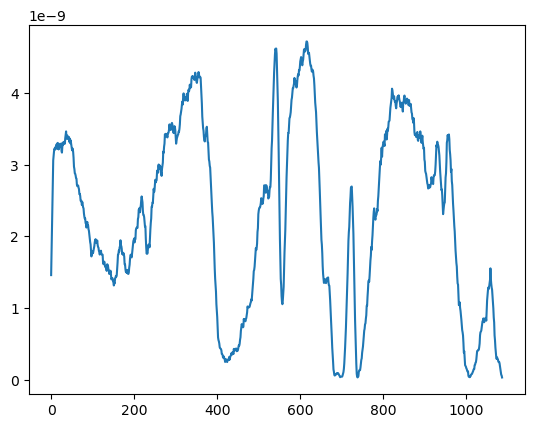

In [19]:
plt.plot(model_amplitude)

In [18]:
model_df = pd.read_csv(path+'\\model_{}.csv'.format(event))

if wave_type == 'S':
    model_error = np.sqrt(model_df[event+'_SV']**2+model_df[event+'_SH']**2)
    model_amplitude= np.sqrt(model_df[event+'_error_SV']**2+model_df[event+'_error_SH']**2)

else:
    model_error  = np.abs(model_df[event+'_'+wave_type])
    model_amplitude = model_df[event+'_error_'+wave_type]

model_amplitude = np.convolve(model_error, np.ones(smoothing_channel)/smoothing_channel, mode='same')



In [20]:
DAS_measure_df = pd.read_csv(path+'\\RMS_{}_{}.csv'.format(event,df_numeber ))
DAS_amplitude = DAS_measure_df['RMS'][first_channel:last_channel]
DAS_amplitude = 11.6*DAS_amplitude*1e-9
DAS_amplitude = np.convolve(DAS_amplitude, np.ones(smoothing_channel)/smoothing_channel, mode='same')
DAS_error = DAS_measure_df['RMS_error'][first_channel:last_channel]
channels = DAS_measure_df['channel'][first_channel:last_channel]
measuretype = DAS_measure_df['status'][first_channel:last_channel]
pick_mask = np.where(measuretype == 'measured', True, False)



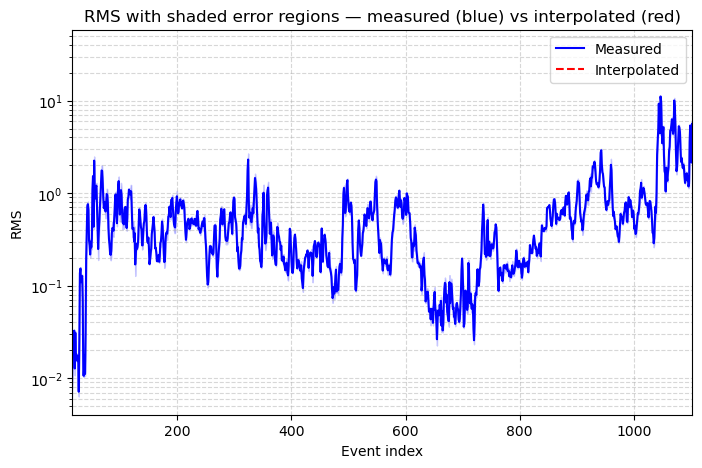

In [21]:
import matplotlib.pyplot as plt
import numpy as np

df = DAS_measure_df

# Separate measured and interpolated data
measured = df[df['status'] == 'measured']
interpolated = df[df['status'] == 'interpolated']

plt.figure(figsize=(8, 5))

# --- Measured data (blue) ---
x_m = measured.index
y_m = measured['RMS'].values
err_m = measured['RMS_error'].values

plt.plot(x_m, y_m, color='blue', label='Measured')
plt.fill_between(x_m, y_m - err_m, y_m + err_m, color='blue', alpha=0.2)

# --- Interpolated data (red) ---
x_i = interpolated.index
y_i = interpolated['RMS'].values
err_i = interpolated['RMS_error'].values

plt.plot(x_i, y_i, color='red', label='Interpolated', linestyle='--')
plt.fill_between(x_i, y_i - err_i, y_i + err_i, color='red', alpha=0.2)

# --- Formatting ---
plt.yscale('log')
plt.xlabel("Event index")
plt.ylabel("RMS")
plt.title("RMS with shaded error regions — measured (blue) vs interpolated (red)")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.xlim(first_channel, last_channel)

plt.show()

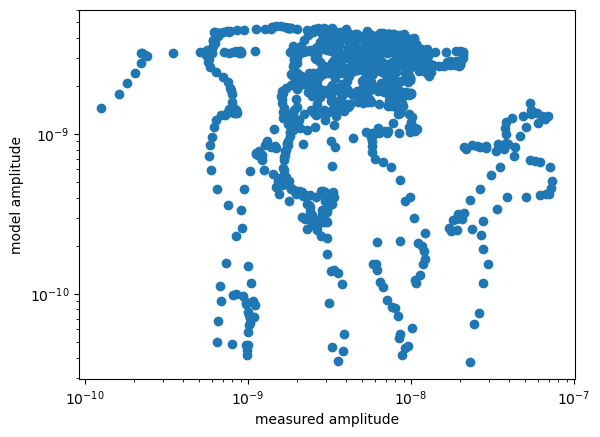

In [22]:
plt.scatter(DAS_amplitude, model_amplitude)
plt.xlabel('measured amplitude')
plt.ylabel('model amplitude')
plt.yscale('log')
plt.xscale('log')

In [7]:
### RUN linear regression ###

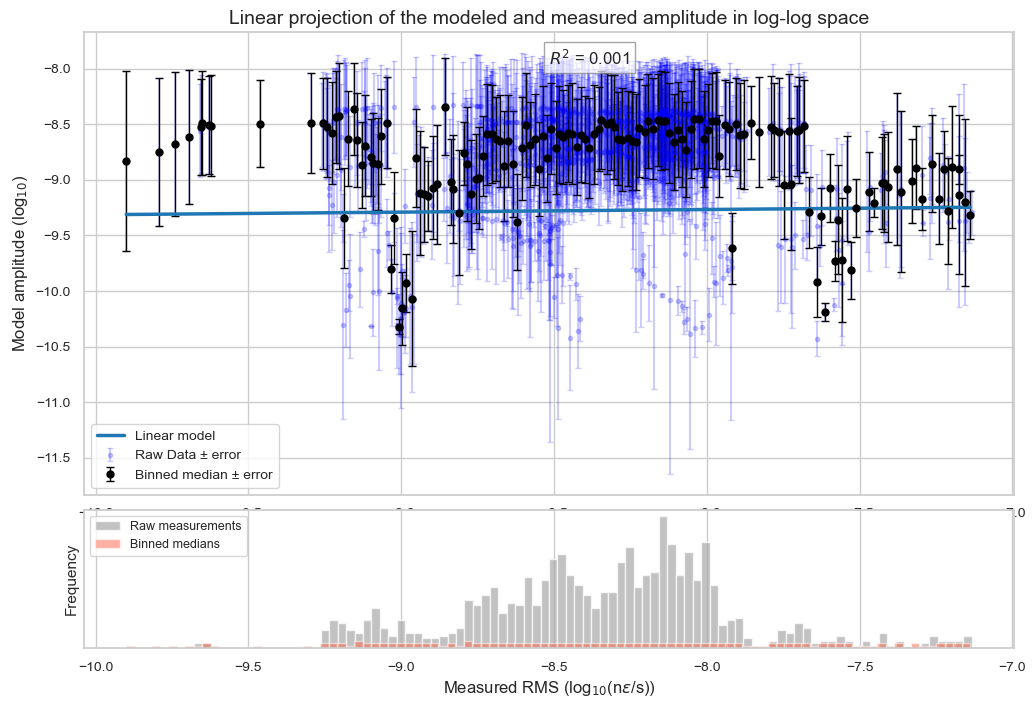

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import binned_statistic
import seaborn as sns

# Apply seaborn style
sns.set(style="whitegrid")

# --- CLEAN DATA ---
valid_mask = ~np.isnan(model_amplitude) & ~np.isnan(DAS_amplitude) & pick_mask 
measurement = DAS_amplitude[valid_mask]
model = model_amplitude[valid_mask]
measurement_error = model_error[valid_mask]

# Convert to log
measurement_log = np.log10(measurement)
model_log = np.log10(model)
measurement_error_log = measurement_error / (model * np.log(10))

# --- BINNING ---
n_bins = 200
bin_stat_mean_meas, bin_edges, _ = binned_statistic(measurement_log, measurement_log, statistic='median', bins=n_bins)
bin_stat_mean_model = binned_statistic(measurement_log, model_log, statistic='median', bins=n_bins)[0]
bin_stat_error = binned_statistic(measurement_log, measurement_error_log, statistic='median', bins=n_bins)[0]

# Remove NaNs after binning
valid_bins = ~np.isnan(bin_stat_mean_meas) & ~np.isnan(bin_stat_mean_model) & ~np.isnan(bin_stat_error)
X_binned = sm.add_constant(bin_stat_mean_meas[valid_bins])
y_binned = bin_stat_mean_model[valid_bins]
weights_binned = 1 / (bin_stat_error[valid_bins] ** 2)

# --- FIT WLS ON BINNED DATA ---
model_binned = sm.WLS(y_binned, X_binned, weights=weights_binned)
results_binned = model_binned.fit()
y_pred_binned = results_binned.predict(X_binned)

# Confidence interval for regression
pred_summary = results_binned.get_prediction(X_binned).summary_frame(alpha=0.05)
ci_lower_binned = pred_summary["mean_ci_lower"]
ci_upper_binned = pred_summary["mean_ci_upper"]




# ---- STEP 3: Use params to get predictions for UNBINNED data ----
X_unbinned = sm.add_constant(measurement_log)
y_pred_unbinned = results_binned.predict(X_unbinned)

# ---- STEP 4: Compute unbinned residuals ----
residuals = model_log - y_pred_unbinned


# --- PLOTTING ---
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[4, 1.2], hspace=0.05)

# Axes
ax_main = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_main)

# --- MAIN PLOT ---
# All data (transparent)
ax_main.errorbar(
    measurement_log,
    model_log,
    yerr=measurement_error_log,
    fmt='o',
    alpha=0.2,
    label='Raw Data ± error',
    color='blue',
    markersize=3,
    capsize=2
)

# Binned points
ax_main.errorbar(
    bin_stat_mean_meas[valid_bins],
    bin_stat_mean_model[valid_bins],
    yerr=bin_stat_error[valid_bins],
    fmt='o',
    color='black',
    ecolor='black',
    elinewidth=1,
    capsize=3,
    markersize=5,
    label='Binned median ± error'
)

# Regression line
ax_main.plot(
    bin_stat_mean_meas[valid_bins],
    y_pred_binned,
    color='#1f77b4',
    linewidth=2.5,
    label='Linear model'
)

'''# Confidence interval
ax_main.fill_between(
    bin_stat_mean_meas[valid_bins],
    ci_lower_binned,
    ci_upper_binned,
    color='#1f77b4',
    alpha=0.2,
    label='95% Confidence Interval'
)'''

# Decorations
ax_main.set_ylabel("Model amplitude (log$_{10}$)", fontsize=12)
ax_main.set_title("Linear projection of the modeled and measured amplitude in log-log space", fontsize=14)
ax_main.legend(fontsize=10)
ax_main.text(
    0.5, 0.93,
    f"$R^2$ = {results_binned.rsquared:.3f}",
    transform=ax_main.transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)
ax_main.set_xlabel(None)
# --- HISTOGRAM ---
ax_bottom.hist(measurement_log, bins=100, color='darkgray', alpha=0.7, label='Raw measurements')
ax_bottom.hist(bin_stat_mean_meas[valid_bins], bins=100, color='tomato', alpha=0.5, label='Binned medians')
ax_bottom.set_ylabel("Frequency", fontsize=11)
ax_bottom.set_xlabel("Measured RMS (log$_{10}$(n$\epsilon$/s))", fontsize=12)
ax_bottom.legend(loc='upper left', fontsize=9)
ax_bottom.set_yticks([])

# Layout adjustments
for ax in [ax_main, ax_bottom]:
    ax.tick_params(labelsize=10)

#sns.despine(trim=True)
#plt.tight_layout()
plt.show()


In [24]:
### Plot amplitude model and residual ###

In [25]:
position = 0
container_residuals = np.array([])
for value_quality in valid_mask:
    if value_quality:
        container_residuals = np.append(container_residuals, -residuals[position])
        position += 1

    else: 
        container_residuals = np.append(container_residuals, np.nan)


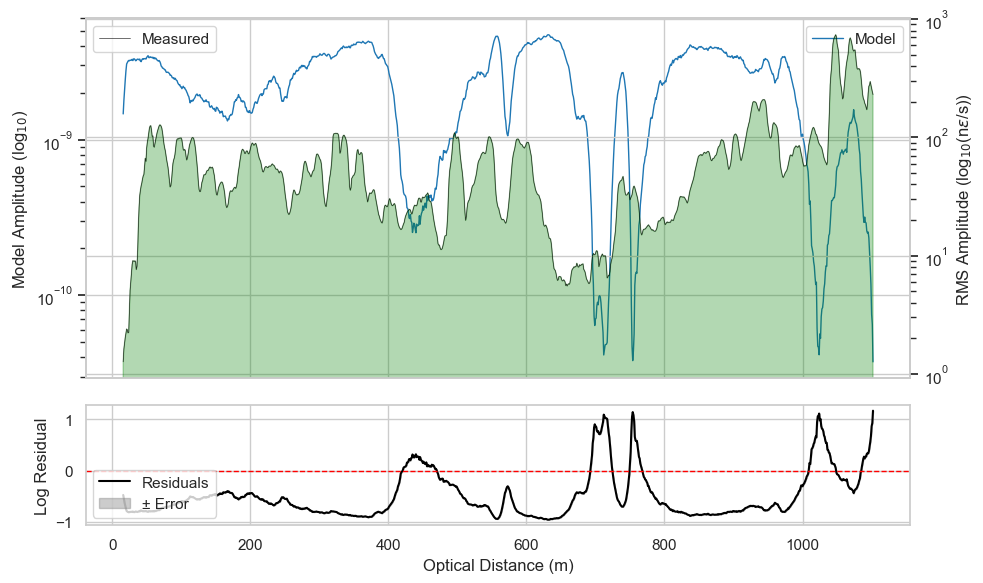

In [26]:
# Create subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

# ==== Plot 1: Amplitudes ====
ax1.plot(channels, model_amplitude, label="Model",lw = 1, color="tab:blue")
ax1.set_yscale('log')

# Twin axis to fill under measured amplitude
ax1_twin = ax1.twinx()
ax1_twin.set_yscale('log')
ax1_twin.plot(channels, DAS_amplitude*10e9, label="Measured",lw = 0.5, color="black", alpha=0.8)
ax1_twin.fill_between(channels, 0, DAS_amplitude*10e9, where=pick_mask, color='green', alpha=0.3)
ax1_twin.fill_between(channels, 0, DAS_amplitude*10e9, where=~pick_mask, color='red', alpha=0.3)
#ax1_twin.set_yticks([])  # hide y-axis ticks

# Legends
ax1.legend(loc="upper right")
ax1.set_ylabel("Model Amplitude (log$_{10}$)")
ax1_twin.set_ylabel("RMS Amplitude (log$_{10}$(n$\epsilon$/s))")
ax1_twin.legend(loc="upper left")

# ==== Plot 2: Residuals with error ====
ax2.plot(channels, container_residuals, label="Residuals", color='black')
ax2.fill_between(channels, container_residuals - model_error, container_residuals + model_error,
                 color='gray', alpha=0.4, label="± Error")

ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel("Optical Distance (m)")
ax2.set_ylabel("Log Residual")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
Residuals_df['residual_'+str(sweep_number)] = container_residuals
Residuals_df['error_'+str(sweep_number)] = model_error
Residuals_df['r2_'+str(sweep_number)] =results_binned.rsquared


In [ ]:
Residuals_df

,residual_4849,error_4849,r2_4849,residual_4850,error_4850,r2_4850,residual_4851,error_4851,r2_4851
0,NaN,NaN,0.694574,NaN,NaN,0.680231,NaN,NaN,0.659891
1,NaN,NaN,0.694574,NaN,NaN,0.680231,NaN,NaN,0.659891
2,NaN,NaN,0.694574,NaN,NaN,0.680231,NaN,NaN,0.659891
3,NaN,NaN,0.694574,NaN,NaN,0.680231,NaN,NaN,0.659891
4,NaN,NaN,0.694574,NaN,NaN,0.680231,NaN,NaN,0.659891
...,...,...,...,...,...,...,...,...,...
779,0.807433,0.108723,0.694574,0.916688,0.108723,0.680231,1.033950,0.108723,0.659891
780,0.410191,0.122641,0.694574,NaN,0.122641,0.680231,0.565422,0.122641,0.659891
781,0.395619,0.119810,0.694574,NaN,0.119810,0.680231,0.614992,0.119810,0.659891
782,-0.049619,0.101525,0.694574,NaN,0.101525,0.680231,NaN,0.101525,0.659891


In [ ]:
Residuals_df.index = channels
Residuals_df.to_csv(r'C:\Users\liliv\Desktop\Brady Hot Springs\sensitivity_gid\sensitivity\residual_error_site{}.csv'.format(site))